In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer 


In [2]:
df=pd.read_csv(r"D:\thirdyear\semster2\NLP\section\nlp_dataset.csv")

In [3]:
df

,text,label,label_name
0,From: shippert@cco.caltech.edu (Tim Shippert)\...,9,rec.sport.baseball
1,From: mont@netcom.com (Mont Pierce)\nSubject: ...,12,sci.electronics
2,From: Amruth Laxman <al26+@andrew.cmu.edu>\nSu...,14,sci.space
3,From: kbanaian@bernard.pitzer.claremont.edu (K...,18,talk.politics.misc
4,From: mcelwre@cnsvax.uwec.edu\nSubject: FREE-E...,0,alt.atheism
...,...,...,...
6995,From: Mamatha Devineni Ratnam <mr47+@andrew.cm...,10,rec.sport.hockey
6996,From: cobb@alexia.lis.uiuc.edu (Mike Cobb)\nSu...,0,alt.atheism
6997,Organization: Central Michigan University\nFro...,7,rec.autos
6998,From: an030@cleveland.Freenet.Edu (Broward Hor...,18,talk.politics.misc


In [4]:
df['label_name'].value_counts()

label_name
rec.sport.hockey            389
comp.windows.x              382
rec.autos                   381
comp.sys.mac.hardware       379
rec.sport.baseball          372
sci.crypt                   372
sci.electronics             370
soc.religion.christian      370
comp.graphics               362
sci.space                   361
comp.os.ms-windows.misc     360
rec.motorcycles             359
misc.forsale                357
comp.sys.ibm.pc.hardware    351
sci.med                     351
talk.politics.mideast       345
talk.politics.guns          333
talk.politics.misc          293
alt.atheism                 285
talk.religion.misc          228
Name: count, dtype: int64

In [5]:
df['label_name'].value_counts().count()

np.int64(20)

In [6]:
df.isna().sum()

text          0
label         0
label_name    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC 

from sklearn.metrics import classification_report,confusion_matrix,accuracy_score


# Preprocessing

In [9]:
stop_words = set(stopwords.words('english'))

In [10]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [11]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

In [12]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    return ' '.join(words)

In [13]:

df['clean_text'] = df['text'].apply(clean_text)

print(df[['text', 'clean_text']].head())

                                                text  \
0  From: shippert@cco.caltech.edu (Tim Shippert)\...   
1  From: mont@netcom.com (Mont Pierce)\nSubject: ...   
2  From: Amruth Laxman <al26+@andrew.cmu.edu>\nSu...   
3  From: kbanaian@bernard.pitzer.claremont.edu (K...   
4  From: mcelwre@cnsvax.uwec.edu\nSubject: FREE-E...   

                                          clean_text  
0  shippert cco caltech edu tim shippert subject ...  
1  mont netcom com mont pierce subject microcontr...  
2  amruth laxman andrew cmu edu subject surviving...  
3  kbanaian bernard pitzer claremont edu king ban...  
4  mcelwre cnsvax uwec edu subject free energy te...  


In [14]:
X = df['clean_text']
y = df['label_name']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [17]:
lr_model = LogisticRegression(max_iter=2000)

lr_model.fit(X_train_vec, y_train)

lr_pred = lr_model.predict(X_test_vec)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy:
0.865
                          precision    recall  f1-score   support

             alt.atheism       0.88      0.91      0.90        57
           comp.graphics       0.71      0.81      0.76        73
 comp.os.ms-windows.misc       0.83      0.79      0.81        72
comp.sys.ibm.pc.hardware       0.68      0.80      0.74        70
   comp.sys.mac.hardware       0.84      0.84      0.84        76
          comp.windows.x       0.91      0.82      0.86        76
            misc.forsale       0.78      0.82      0.80        71
               rec.autos       0.91      0.89      0.90        76
         rec.motorcycles       0.96      0.92      0.94        72
      rec.sport.baseball       0.92      0.88      0.90        74
        rec.sport.hockey       0.93      0.97      0.95        78
               sci.crypt       1.00      0.93      0.97        74
         sci.electronics       0.77      0.76      0.76        74
                 sci.med       0.92    

In [18]:
nb_model = MultinomialNB()

nb_model.fit(X_train_vec, y_train)

nb_pred = nb_model.predict(X_test_vec)

print("Naive Bayes Accuracy:")
print(accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy:
0.8328571428571429
                          precision    recall  f1-score   support

             alt.atheism       0.89      0.89      0.89        57
           comp.graphics       0.74      0.75      0.75        73
 comp.os.ms-windows.misc       0.88      0.69      0.78        72
comp.sys.ibm.pc.hardware       0.72      0.80      0.76        70
   comp.sys.mac.hardware       0.79      0.87      0.82        76
          comp.windows.x       0.81      0.92      0.86        76
            misc.forsale       0.75      0.73      0.74        71
               rec.autos       0.80      0.89      0.84        76
         rec.motorcycles       0.97      0.88      0.92        72
      rec.sport.baseball       0.93      0.84      0.88        74
        rec.sport.hockey       0.82      0.95      0.88        78
               sci.crypt       0.90      0.93      0.91        74
         sci.electronics       0.82      0.64      0.72        74
                 sci.med       0.9

In [19]:
# svm_model = LinearSVC(
#     C=1.5,
#     max_iter=5000
# )
svm_model = LinearSVC(
    C=3,
    class_weight='balanced',
    max_iter=10000
)

svm_model.fit(X_train_vec, y_train)

svm_pred = svm_model.predict(X_test_vec)

print("Linear SVM Accuracy:")
print(accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

Linear SVM Accuracy:
0.89
                          precision    recall  f1-score   support

             alt.atheism       0.86      0.95      0.90        57
           comp.graphics       0.83      0.81      0.82        73
 comp.os.ms-windows.misc       0.82      0.85      0.84        72
comp.sys.ibm.pc.hardware       0.69      0.76      0.72        70
   comp.sys.mac.hardware       0.85      0.87      0.86        76
          comp.windows.x       0.93      0.84      0.88        76
            misc.forsale       0.79      0.79      0.79        71
               rec.autos       0.93      0.88      0.91        76
         rec.motorcycles       0.99      0.92      0.95        72
      rec.sport.baseball       0.95      0.93      0.94        74
        rec.sport.hockey       0.95      1.00      0.97        78
               sci.crypt       1.00      0.96      0.98        74
         sci.electronics       0.81      0.81      0.81        74
                 sci.med       0.90      0.93    

In [20]:
results = {
    'Logistic Regression': accuracy_score(y_test, lr_pred),
    'Naive Bayes': accuracy_score(y_test, nb_pred),
    'Linear SVM': accuracy_score(y_test, svm_pred)
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 0.8650
Naive Bayes: 0.8329
Linear SVM: 0.8900


In [21]:
best_model = max(results, key=results.get)

print("Best Model:", best_model)
print("Best Accuracy:", results[best_model])

Best Model: Linear SVM
Best Accuracy: 0.89


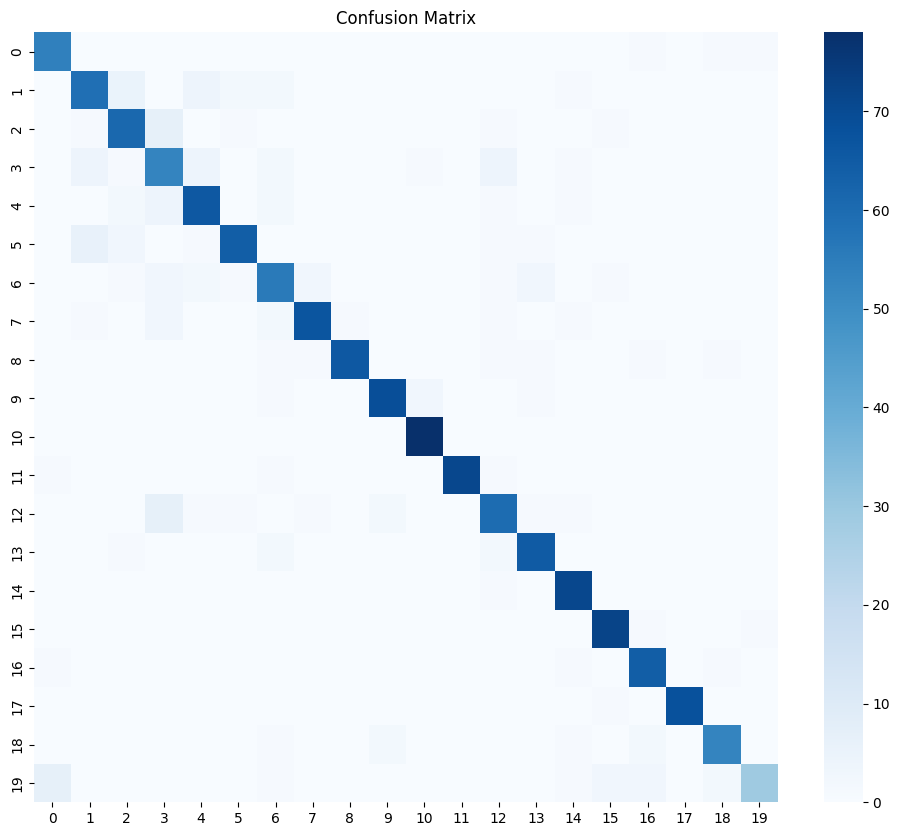

In [22]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Deep learning & NN  Phase 

In [23]:
X_train_dl = X_train_vec.toarray()

X_test_dl = X_test_vec.toarray()

In [61]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)



In [62]:
X_train_dl = X_train_vec.toarray()

X_test_dl = X_test_vec.toarray()

In [26]:
# !pip install tensorflow

In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [64]:
model = Sequential()

In [65]:
model.add(Dense(
    256,
    activation='relu',
    input_shape=(X_train_dl.shape[1],)
))

c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [66]:
model.add(Dropout(0.3))

In [67]:
model.add(Dense(128, activation='relu'))

model.add(Dropout(0.3))

In [68]:
model.add(Dense(len(np.unique(y_train)), activation='softmax'))

In [69]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [70]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [71]:
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

history = model.fit(
    X_train_dl,
    y_train_encoded,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.4592 - loss: 2.2526 - val_accuracy: 0.8098 - val_loss: 1.0170
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.8946 - loss: 0.5132 - val_accuracy: 0.8545 - val_loss: 0.5214
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.9828 - loss: 0.1173 - val_accuracy: 0.8598 - val_loss: 0.4634
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.9953 - loss: 0.0436 - val_accuracy: 0.8598 - val_loss: 0.4616
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.9980 - loss: 0.0211 - val_accuracy: 0.8554 - val_loss: 0.4719
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.9987 - loss: 0.0159 - val_accuracy: 0.8616 - val_loss: 0.4739
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.9987 - loss: 0.0128 - val_accuracy: 0.8536 - val_loss: 0.4832


# evaluating model 


In [73]:
loss, accuracy = model.evaluate(X_test_dl, y_test_encoded)

print("DL Model Accuracy:", accuracy)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8829 - loss: 0.4044
DL Model Accuracy: 0.8828571438789368


# LLM

In [74]:
from transformers import pipeline
classifier = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1532.79it/s]


DistilBERT: نسخة أخف وأسرع من BERT.

ومتدربة على: sentiment analysis



In [75]:
sample_text = df['text'][0]

result = classifier(sample_text)

print(result)



[{'label': 'NEGATIVE', 'score': 0.9986326098442078}]


Observation

The pre-trained model was trained for sentiment analysis and did not perform well on our custom dataset categories.

Therefore, fine-tuning was required.

# fine tuning 

In [76]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['label_encoded'] = encoder.fit_transform(df['label_name'])

In [77]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label_encoded']
)

In [78]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[['text', 'label_encoded']]
)

test_dataset = Dataset.from_pandas(
    test_df[['text', 'label_encoded']]
)

In [92]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

def tokenize(batch):

    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

In [93]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

def tokenize(batch):

    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)

test_dataset = test_dataset.map(tokenize, batched=True)

Map: 100%|██████████| 1400/1400 [00:01<00:00, 773.85 examples/s]


In [94]:
train_dataset.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'labels']
)

test_dataset.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'labels']
)

In [96]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "prajjwal1/bert-tiny",
    num_labels=len(df['label_encoded'].unique())
)

c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Dell\.cache\huggingface\hub\models--prajjwal1--bert-tiny. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


ValueError: Unrecognized model in prajjwal1/bert-tiny. Should have a `model_type` key in its config.json.

In [97]:
from nltk import tokenize


def tokenize(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

test_dataset = test_dataset.map(tokenize, batched=True)

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(df['label_encoded'].unique())
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2908.87it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [98]:
from transformers import TrainingArguments

In [99]:
training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01
)

from transformers import Trainer

trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset
)


In [100]:
trainer.train()



c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,2.047855


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.00it/s]


TrainOutput(global_step=700, training_loss=1.8717211042131696, metrics={'train_runtime': 2897.1904, 'train_samples_per_second': 1.933, 'train_steps_per_second': 0.242, 'total_flos': 185513889792000.0, 'train_loss': 1.8717211042131696, 'epoch': 1.0})

In [101]:
trainer.evaluate()

c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step
2.047855,1.288675,700


{'eval_loss': 1.2886754274368286}

In [102]:
import joblib

joblib.dump(svm_model, 'svm_model.pkl')
joblib.dump(vectorizer, 'tfidf.pkl')

['tfidf.pkl']

In [103]:
model = joblib.load('svm_model.pkl')
vectorizer = joblib.load('tfidf.pkl')